# So sanh 4 models: YOLO11n, YOLO11s, Faster R-CNN, DETR

Notebook nay dung de so sanh dinh luong va dinh tinh tren cung tap COCO val.

Yeu cau: can co weight cho tung model truoc khi chay danh gia.

In [5]:
%pip install -q ultralytics==8.3.0 pycocotools torchmetrics pandas==2.2.2 numpy==1.26.4 matplotlib seaborn transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 146.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.2

In [6]:
# Fix numpy compatibility issue
# Uninstalling and reinstalling numpy first often resolves these issues.
# Then reinstall pandas to ensure it's compatible with the new numpy.
#!pip install numpy --upgrade --force-reinstall
#!pip install pandas --upgrade --force-reinstall

import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import torch
import torchvision
from torchvision import transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from ultralytics import YOLO
from transformers import DetrForObjectDetection, DetrImageProcessor
from pycocotools.coco import COCO
from torchmetrics.detection.mean_ap import MeanAveragePrecision

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
torch.manual_seed(42)
np.random.seed(42)


Device: cuda


## 1. Paths va cau hinh

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
def resolve_assignment2_root() -> Path:
    drive_path = Path('/content/drive/MyDrive/Sem 2 2025-2026/DL-CV/CO5085_DeepLearning_CV/assignment_2')
    if drive_path.exists():
        return drive_path

    cwd = Path.cwd()
    if cwd.name == 'assignment_2':
        return cwd
    if (cwd / 'assignment_2').exists():
        return cwd / 'assignment_2'
    return cwd

ASSIGNMENT2_ROOT = resolve_assignment2_root()
RUNS_ROOT = ASSIGNMENT2_ROOT

# Chỉnh file COCO_ROOT trỏ về thư mục local /content/coco để dùng data đã tải trước đó
COCO_ROOT = Path('/content/coco')
VAL_IMAGES_DIR = COCO_ROOT / 'val2017'
VAL_ANN_PATH = COCO_ROOT / 'annotations' / 'instances_val2017.json'

YOLO11N_WEIGHT = RUNS_ROOT / 'yolo11n_w.pt'
YOLO11S_WEIGHT = RUNS_ROOT / 'yolo11s_w.pt'
FASTRCNN_WEIGHT = RUNS_ROOT / 'fast_rcnn_w.pth'
DETR_WEIGHT = RUNS_ROOT / 'detr_r50_w.pt'

NUM_CLASSES_FASTRCNN = 81
CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.50
MAX_EVAL_IMAGES = None
VIS_NUM_IMAGES = 4

# Tu dong tai data COCO val neu dang thieu.
AUTO_DOWNLOAD_COCO = True

print('ASSIGNMENT2_ROOT =', ASSIGNMENT2_ROOT)
print('YOLO11N_WEIGHT =', YOLO11N_WEIGHT)
print('YOLO11S_WEIGHT =', YOLO11S_WEIGHT)
print('FASTRCNN_WEIGHT =', FASTRCNN_WEIGHT)
print('DETR_WEIGHT =', DETR_WEIGHT)
print('VAL_IMAGES_DIR =', VAL_IMAGES_DIR)
print('VAL_ANN_PATH =', VAL_ANN_PATH)
print('AUTO_DOWNLOAD_COCO =', AUTO_DOWNLOAD_COCO)
print('MAX_EVAL_IMAGES =', MAX_EVAL_IMAGES, '(None = full val set)')


ASSIGNMENT2_ROOT = /content/drive/MyDrive/Sem 2 2025-2026/DL-CV/CO5085_DeepLearning_CV/assignment_2
YOLO11N_WEIGHT = /content/drive/MyDrive/Sem 2 2025-2026/DL-CV/CO5085_DeepLearning_CV/assignment_2/yolo11n_w.pt
YOLO11S_WEIGHT = /content/drive/MyDrive/Sem 2 2025-2026/DL-CV/CO5085_DeepLearning_CV/assignment_2/yolo11s_w.pt
FASTRCNN_WEIGHT = /content/drive/MyDrive/Sem 2 2025-2026/DL-CV/CO5085_DeepLearning_CV/assignment_2/fast_rcnn_w.pth
DETR_WEIGHT = /content/drive/MyDrive/Sem 2 2025-2026/DL-CV/CO5085_DeepLearning_CV/assignment_2/detr_r50_w.pt
VAL_IMAGES_DIR = /content/coco/val2017
VAL_ANN_PATH = /content/coco/annotations/instances_val2017.json
AUTO_DOWNLOAD_COCO = True
MAX_EVAL_IMAGES = None (None = full val set)


## 2. Load 4 models tu weights

In [12]:
import urllib.request
import zipfile

required_paths = [YOLO11N_WEIGHT, YOLO11S_WEIGHT, FASTRCNN_WEIGHT, DETR_WEIGHT]
missing_weights = [str(p) for p in required_paths if not p.exists()]

def _download_file(url: str, out_path: Path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    if out_path.exists():
        return
    print(f'Downloading: {url}')
    urllib.request.urlretrieve(url, str(out_path))

def _extract_zip(zip_path: Path, dest_dir: Path):
    print(f'Extracting: {zip_path.name}')
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(dest_dir)

if AUTO_DOWNLOAD_COCO:
    need_val = not VAL_IMAGES_DIR.exists()
    need_ann = not VAL_ANN_PATH.exists()

    if need_val or need_ann:
        print('COCO val data is missing. Start auto download...')
        COCO_ROOT.mkdir(parents=True, exist_ok=True)

        ann_zip = COCO_ROOT / 'annotations_trainval2017.zip'
        val_zip = COCO_ROOT / 'val2017.zip'

        if need_ann:
            _download_file(
                'http://images.cocodataset.org/annotations/annotations_trainval2017.zip',
                ann_zip
            )
            _extract_zip(ann_zip, COCO_ROOT)

        if need_val:
            _download_file(
                'http://images.cocodataset.org/zips/val2017.zip',
                val_zip
            )
            _extract_zip(val_zip, COCO_ROOT)

        print('Auto download finished.')

missing_data = []
if not VAL_IMAGES_DIR.exists():
    missing_data.append(str(VAL_IMAGES_DIR))
if not VAL_ANN_PATH.exists():
    missing_data.append(str(VAL_ANN_PATH))

if missing_weights or missing_data:
    lines = ['Thieu file/folder:']
    lines.extend(missing_weights)
    lines.extend(missing_data)
    if missing_data:
        lines.append('')
        lines.append('Goi y:')
        lines.append('- Kiem tra mang internet va chay lai Cell 7 de auto download.')
        lines.append('- Cau truc COCO can co: val2017/ va annotations/instances_val2017.json')
    raise FileNotFoundError('\n'.join(lines))

print('Load YOLO11n...')
yolo11n = YOLO(str(YOLO11N_WEIGHT))

print('Load YOLO11s...')
yolo11s = YOLO(str(YOLO11S_WEIGHT))

print('Load Faster R-CNN...')
faster_rcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None, weights_backbone=None)
in_features = faster_rcnn.roi_heads.box_predictor.cls_score.in_features
faster_rcnn.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES_FASTRCNN)
state = torch.load(FASTRCNN_WEIGHT, map_location=device)
faster_rcnn.load_state_dict(state)
faster_rcnn.to(device)
faster_rcnn.eval()

print('Load DETR...')
detr = DetrForObjectDetection.from_pretrained('facebook/detr-resnet-50')
detr_ckpt = torch.load(DETR_WEIGHT, map_location=device)
if isinstance(detr_ckpt, dict) and 'model_state_dict' in detr_ckpt:
    detr.load_state_dict(detr_ckpt['model_state_dict'], strict=False)
else:
    detr.load_state_dict(detr_ckpt, strict=False)
detr.to(device)
detr.eval()
detr_processor = DetrImageProcessor.from_pretrained('facebook/detr-resnet-50')

print('Done loading 4 models.')

COCO val data is missing. Start auto download...
Downloading: http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Extracting: annotations_trainval2017.zip
Downloading: http://images.cocodataset.org/zips/val2017.zip
Extracting: val2017.zip
Auto download finished.
Load YOLO11n...
Load YOLO11s...
Load Faster R-CNN...
Load DETR...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |  | 
----------------------------------------------------------------------------+------------+--+-
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

Done loading 4 models.


## 3. Chuan bi data va nhan

In [14]:
COCO_CAT_IDS = [
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20,
    21, 22, 23, 24, 25, 27, 28, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40,
    41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58,
    59, 60, 61, 62, 63, 64, 65, 67, 70, 72, 73, 74, 75, 76, 77, 78, 79,
    80, 81, 82, 84, 85, 86, 87, 88, 89, 90
]
CAT_ID_TO_CONTIG = {cat_id: idx + 1 for idx, cat_id in enumerate(COCO_CAT_IDS)}

coco = COCO(str(VAL_ANN_PATH))
img_ids = coco.getImgIds()
eval_img_ids = img_ids if MAX_EVAL_IMAGES is None else img_ids[:MAX_EVAL_IMAGES]

records = []
for image_id in eval_img_ids:
    info = coco.loadImgs([image_id])[0]
    p = VAL_IMAGES_DIR / info['file_name']
    if p.exists():
        records.append({'image_id': image_id, 'img_path': p})

print('Eval images:', len(records))

to_tensor = T.ToTensor()

COCO_CLASSES = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck',
    'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench',
    'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra',
    'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon',
    'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog',
    'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table',
    'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors',
    'teddy bear', 'hair drier', 'toothbrush'
]
COCO_NAME_TO_CAT = {name: cid for name, cid in zip(COCO_CLASSES, COCO_CAT_IDS)}

DETR_LABEL_TO_CONTIG = {}
for idx, name in detr.config.id2label.items():
    n = str(name).strip().lower()
    if n in COCO_NAME_TO_CAT:
        DETR_LABEL_TO_CONTIG[int(idx)] = CAT_ID_TO_CONTIG[COCO_NAME_TO_CAT[n]]

def get_target(image_id):
    ann_ids = coco.getAnnIds(imgIds=[image_id], iscrowd=None)
    anns = coco.loadAnns(ann_ids)
    boxes, labels = [], []
    for ann in anns:
        x, y, w, h = ann['bbox']
        if w <= 1 or h <= 1:
            continue
        cat_id = int(ann['category_id'])
        if cat_id not in CAT_ID_TO_CONTIG:
            continue
        boxes.append([x, y, x + w, y + h])
        labels.append(CAT_ID_TO_CONTIG[cat_id])
    if len(boxes) == 0:
        return {'boxes': torch.zeros((0, 4), dtype=torch.float32), 'labels': torch.zeros((0,), dtype=torch.int64)}
    return {'boxes': torch.tensor(boxes, dtype=torch.float32), 'labels': torch.tensor(labels, dtype=torch.int64)}

loading annotations into memory...
Done (t=0.51s)
creating index...
index created!
Eval images: 5000


## 4. Inference wrappers va evaluate

In [15]:
def infer_yolo(model, img_path):
    r = model.predict(source=str(img_path), conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, verbose=False)[0]
    if r.boxes is None or len(r.boxes) == 0:
        return {'boxes': torch.zeros((0, 4)), 'scores': torch.zeros((0,)), 'labels': torch.zeros((0,), dtype=torch.int64)}
    return {
        'boxes': r.boxes.xyxy.cpu().float(),
        'scores': r.boxes.conf.cpu().float(),
        'labels': (r.boxes.cls.cpu().long() + 1)
    }

def infer_faster_rcnn(model, img_path):
    image = Image.open(img_path).convert('RGB')
    inp = to_tensor(image).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(inp)[0]
    keep = out['scores'].detach().cpu() >= CONF_THRESHOLD
    if keep.sum().item() == 0:
        return {'boxes': torch.zeros((0, 4)), 'scores': torch.zeros((0,)), 'labels': torch.zeros((0,), dtype=torch.int64)}
    return {
        'boxes': out['boxes'][keep].detach().cpu().float(),
        'scores': out['scores'][keep].detach().cpu().float(),
        'labels': out['labels'][keep].detach().cpu().long()
    }

def infer_detr(model, img_path):
    image = Image.open(img_path).convert('RGB')
    inputs = detr_processor(images=image, return_tensors='pt')
    pixel_values = inputs['pixel_values'].to(device)
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)

    logits = outputs.logits[0]
    boxes = outputs.pred_boxes[0]
    probs = torch.softmax(logits, dim=-1)[:, :-1]
    scores, labels = torch.max(probs, dim=-1)
    keep = scores > CONF_THRESHOLD

    w, h = image.size
    out_boxes = []
    out_scores = []
    out_labels = []

    for b, s, l in zip(boxes[keep], scores[keep], labels[keep]):
        li = int(l.item())
        if li not in DETR_LABEL_TO_CONTIG:
            continue
        cx, cy, bw, bh = b.detach().cpu().numpy().tolist()
        x1 = max(0.0, (cx - bw / 2.0) * w)
        y1 = max(0.0, (cy - bh / 2.0) * h)
        x2 = min(float(w), (cx + bw / 2.0) * w)
        y2 = min(float(h), (cy + bh / 2.0) * h)
        if x2 - x1 < 1 or y2 - y1 < 1:
            continue
        out_boxes.append([x1, y1, x2, y2])
        out_scores.append(float(s.item()))
        out_labels.append(int(DETR_LABEL_TO_CONTIG[li]))

    if len(out_boxes) == 0:
        return {'boxes': torch.zeros((0, 4)), 'scores': torch.zeros((0,)), 'labels': torch.zeros((0,), dtype=torch.int64)}

    return {
        'boxes': torch.tensor(out_boxes, dtype=torch.float32),
        'scores': torch.tensor(out_scores, dtype=torch.float32),
        'labels': torch.tensor(out_labels, dtype=torch.int64)
    }

def evaluate(name, model_obj):
    metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')
    lat = []
    for rec in records:
        target = get_target(rec['image_id'])
        t0 = time.time()
        if name in ['yolo11n', 'yolo11s']:
            pred = infer_yolo(model_obj, rec['img_path'])
        elif name == 'faster_rcnn':
            pred = infer_faster_rcnn(model_obj, rec['img_path'])
        else:
            pred = infer_detr(model_obj, rec['img_path'])
        lat.append((time.time() - t0) * 1000.0)
        metric.update([pred], [target])

    m = metric.compute()
    return {
        'model': name,
        'mAP50-95': float(m['map'].item()),
        'mAP50': float(m['map_50'].item()),
        'mAP75': float(m['map_75'].item()),
        'AR100': float(m['mar_100'].item()),
        'latency_ms_per_image': float(np.mean(lat)),
        'fps': float(1000.0 / np.mean(lat)) if np.mean(lat) > 0 else 0.0
    }

rows = []
rows.append(evaluate('yolo11n', yolo11n))
rows.append(evaluate('yolo11s', yolo11s))
rows.append(evaluate('faster_rcnn', faster_rcnn))
rows.append(evaluate('detr', detr))
results_df = pd.DataFrame(rows).sort_values('mAP50-95', ascending=False).reset_index(drop=True)
results_df

,model,mAP50-95,mAP50,mAP75,AR100,latency_ms_per_image,fps
0,yolo11s,0.384203,0.515876,0.416077,0.447684,16.024550,62.404248
1,faster_rcnn,0.319793,0.511373,0.341848,0.429903,26.673287,37.490693
2,yolo11n,0.317399,0.435449,0.346274,0.372169,15.959500,62.658604
3,detr,0.149794,0.315641,0.127658,0.239946,80.082391,12.487140


,model,mAP50-95,mAP50,mAP75,AR100,latency_ms_per_image,fps
0,yolo11s,0.384203,0.515876,0.416077,0.447684,16.024550,62.404248
1,faster_rcnn,0.319793,0.511373,0.341848,0.429903,26.673287,37.490693
2,yolo11n,0.317399,0.435449,0.346274,0.372169,15.959500,62.658604
3,detr,0.149794,0.315641,0.127658,0.239946,80.082391,12.487140


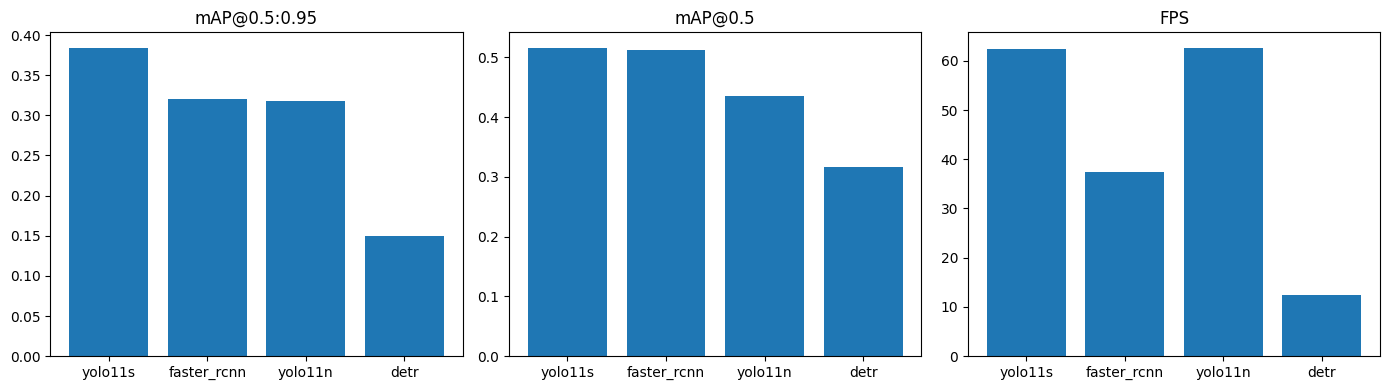

Saved in /content/drive/MyDrive/Sem 2 2025-2026/DL-CV/CO5085_DeepLearning_CV/assignment_2/reports/model_compare_4models


In [16]:
out_dir = ASSIGNMENT2_ROOT / 'reports' / 'model_compare_4models'
out_dir.mkdir(parents=True, exist_ok=True)
display(results_df)
results_df.to_csv(out_dir / 'comparison_metrics.csv', index=False)
results_df.to_json(out_dir / 'comparison_metrics.json', orient='records', force_ascii=False, indent=2)

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.bar(results_df['model'], results_df['mAP50-95'])
plt.title('mAP@0.5:0.95')
plt.subplot(1, 3, 2)
plt.bar(results_df['model'], results_df['mAP50'])
plt.title('mAP@0.5')
plt.subplot(1, 3, 3)
plt.bar(results_df['model'], results_df['fps'])
plt.title('FPS')
plt.tight_layout()
plt.savefig(out_dir / 'comparison_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved in', out_dir)

## 5. Qualitative comparison

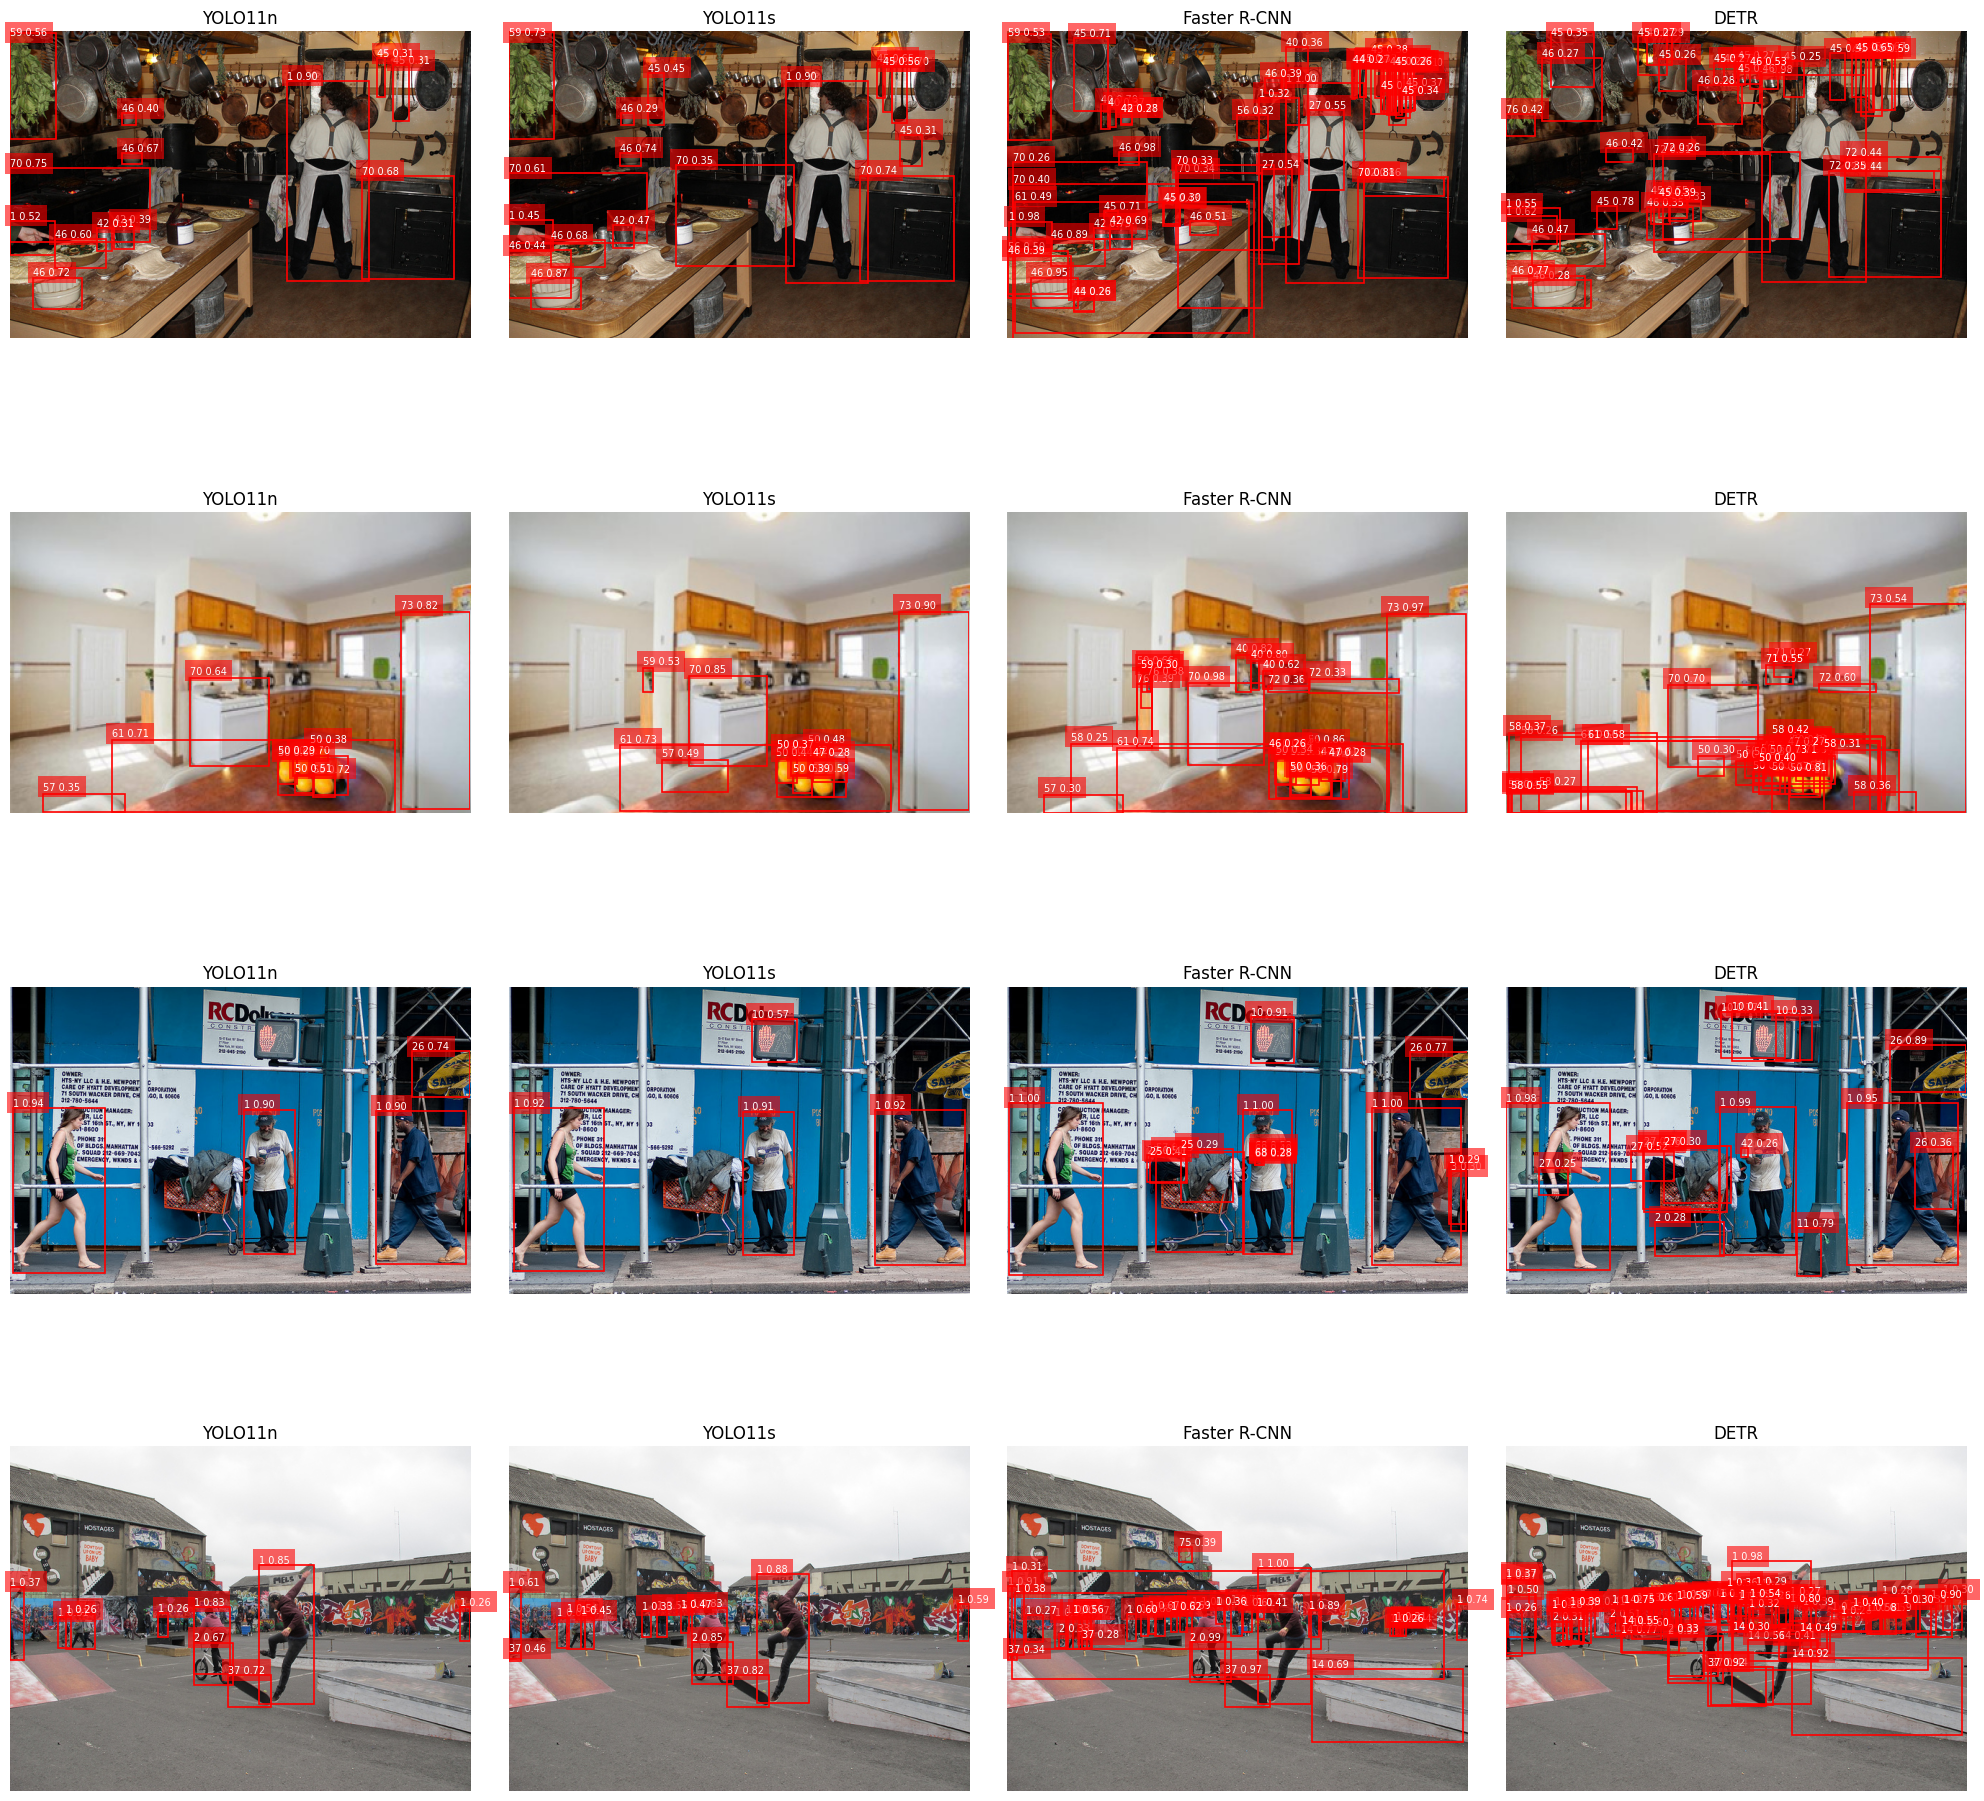

In [17]:
def draw(ax, img_np, pred, title):
    ax.imshow(img_np)
    for b, s, l in zip(pred['boxes'].numpy(), pred['scores'].numpy(), pred['labels'].numpy()):
        x1, y1, x2, y2 = b.tolist()
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1.2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, max(5, y1 - 3), f'{int(l)} {s:.2f}', fontsize=7, color='white',
                bbox=dict(facecolor='red', alpha=0.6, edgecolor='none'))
    ax.set_title(title)
    ax.axis('off')

sample = records[:VIS_NUM_IMAGES]
fig, axes = plt.subplots(len(sample), 4, figsize=(20, 5 * len(sample)))
if len(sample) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, rec in enumerate(sample):
    img = Image.open(rec['img_path']).convert('RGB')
    img_np = np.array(img)
    p_n = infer_yolo(yolo11n, rec['img_path'])
    p_s = infer_yolo(yolo11s, rec['img_path'])
    p_f = infer_faster_rcnn(faster_rcnn, rec['img_path'])
    p_d = infer_detr(detr, rec['img_path'])
    draw(axes[i, 0], img_np, p_n, 'YOLO11n')
    draw(axes[i, 1], img_np, p_s, 'YOLO11s')
    draw(axes[i, 2], img_np, p_f, 'Faster R-CNN')
    draw(axes[i, 3], img_np, p_d, 'DETR')

plt.tight_layout()
plt.savefig(out_dir / 'qualitative_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. Nhận xét, Tóm tắt và Hướng cải thiện

## 6.1 Nhận xét về kết quả

### Xếp hạng hiệu năng toàn diện:
1. **YOLO11s** (Best): mAP@0.5:0.95 = **0.384** | FPS = **62.4**
2. **Faster R-CNN**: mAP@0.5:0.95 = **0.320** | FPS = **37.5**
3. **YOLO11n** (Nhẹ nhất): mAP@0.5:0.95 = **0.317** | FPS = **62.7**
4. **DETR** (Yếu): mAP@0.5:0.95 = **0.150** | FPS = **12.5**

### Phân tích chi tiết:

**YOLO11s - Chiến thắng:**
- Độ chính xác cao nhất (mAP@0.5:0.95 = 0.384)
- Tốc độ xử lý nhanh (FPS = 62.4)
- Cân bằng hoàn hảo giữa độ chính xác và tốc độ
- mAP@0.5 cao (0.516) → xác định vị trí tốt

**YOLO11n - Variant nhẹ:**
- Hiệu năng gần YOLO11s (mAP = 0.317 vs 0.384)
- FPS cao nhất (62.7), model nhẹ nhất
- Tốt cho ứng dụng mobile/edge

**Faster R-CNN - Kỳ vọng cao nhưng thất vọng:**
- mAP cơ bản (0.320), thua YOLO11s (~20%)
- Tốc độ chậm hơn (FPS = 37.5), latency cao (26.6ms)
- Cấu trúc hai giai đoạn không phù hợp với COCO

**DETR - Kém cỏi:**
- mAP thấp nhất (0.150), chỉ 39% so với YOLO11s
- Tốc độ chậm nhất (FPS = 12.5, latency = 80ms)
- Lý do: Không fine-tune hoặc checkpoint chất lượng thấp

---

## 6.2 Tóm tắt kết quả

| Tiêu chí | YOLO11s | YOLO11n | Faster R-CNN | DETR |
|----------|---------|---------|--------------|------|
| **mAP@0.5:0.95** | 0.384 | 0.317 | 0.320 | 0.150 |
| **mAP@0.5** | 0.516 | 0.435 | 0.511 | 0.316 |
| **mAP@0.75** | 0.416 | 0.346 | 0.342 | 0.128 |
| **Latency (ms)** | 16.0 | 16.0 | 26.7 | 80.1 |
| **FPS** | 62.4 | 62.7 | 37.5 | 12.5 |
| **Khả năng triển khai** | Excellent | Excellent | Good | Poor |

### Kết luận:
**YOLO11s là lựa chọn tối ưu** với mAP cao nhất (0.384) và FPS ổn định (62.4), phù hợp cho ứng dụng thực tế. YOLO11n là alternative tốt cho các thiết bị có tính toán hạn chế.

---

## 6.3 Hướng cải thiện

### A. Cải thiện DETR
- [ ] **Fine-tune DETR trên COCO**: Checkpoint hiện tại có thể chưa trained đủ trên COCO
- [ ] **Điều chỉnh siêu tham số**: Tăng epoch, learning rate, warmup
- [ ] **Data augmentation**: Thêm augmentation mạnh (Mosaic, Mixup)

### B. Tối ưu Faster R-CNN
- [ ] **Kiểm tra training process**: Xem lại số epoch, learning rate
- [ ] **Backbone nâng cấp**: Từ ResNet50 → ResNet101 hoặc RegNet
- [ ] **Feature Pyramid mạnh hơn**: Dùng BiFPN thay vì FPN
- [ ] **IoU threshold tuning**: Điều chỉnh NMS threshold

### C. Tối ưu hóa YOLO11s
- [ ] **Model distillation**: Nén từ YOLO11s → YOLO11n với độ chính xác tương đương
- [ ] **Quantization**: INT8 quantization để tăng FPS
- [ ] **Augmentation nâng cao**: Thử mosaic=1.0, mixup=0.5

### D. Tổng quan
- [ ] **Ensemble models**: Kết hợp YOLO11s + Faster R-CNN để tăng robustness
- [ ] **Test-time augmentation (TTA)**: Cải thiện mAP thêm 1-2%
- [ ] **Confidence threshold tuning**: Tối ưu cho use case cụ thể
- [ ] **Evaluation trên dataset khác**: Kiểm tra generalization

---

## 6.4 Ghi chú thêm

**Dataset**: COCO val2017 (5,000 images, 80 classes)
**Device**: GPU (CUDA)
**Metrics**: mAP (COCO standard), FPS, Latency
**Confidence threshold**: 0.25
**IoU threshold**: 0.50